In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [3]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

Found 120 files belonging to 3 classes.
Using 24 files for validation.


E0000 00:00:1778157396.270192  111041 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778157396.270497  111837 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778157396.293044  111041 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


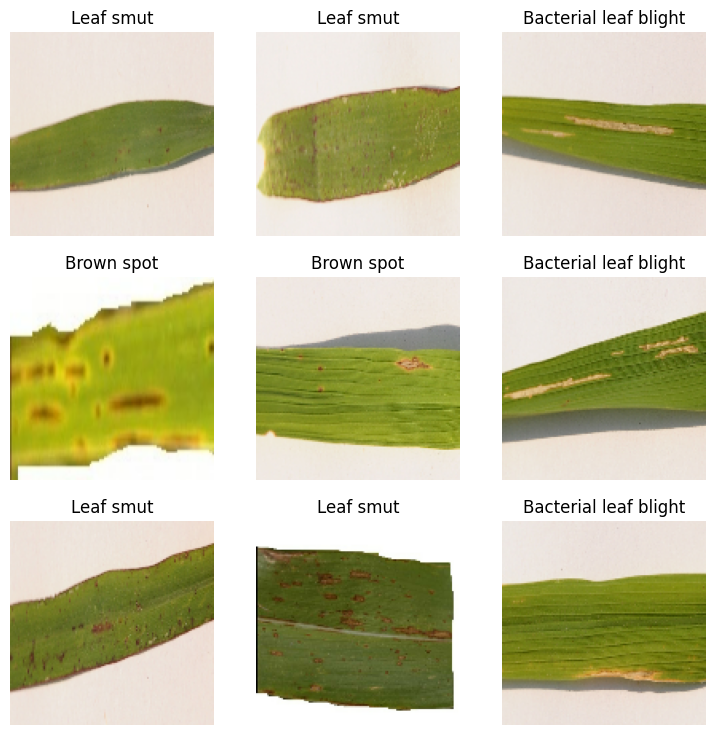

In [4]:
val = tf.keras.preprocessing.image_dataset_from_directory(
    "rice_leaf_diseases", image_size=(128,128), batch_size=32, seed=42, subset="validation", validation_split=0.2
)

plt.figure(figsize=(9,9))
for images, lables in val.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(val.class_names[lables[i]])
        plt.axis('off')
plt.show()

In [5]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

train = image_dataset_from_directory(
    'rice_leaf_diseases', image_size=(128,128), batch_size=32,
    seed=42, validation_split=0.2, subset='training' 
)

Found 120 files belonging to 3 classes.
Using 96 files for training.


In [6]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128,128,3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(train.class_names), activation='softmax')]
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/home/tammy/Documents/collage_shit/lp5/.venv/lib64/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
history = model.fit(train, validation_data=val, epochs=30, verbose=0)

loss, accuracy = model.evaluate(val)
print(loss, accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6250 - loss: 1.7923
1.7922664880752563 0.625


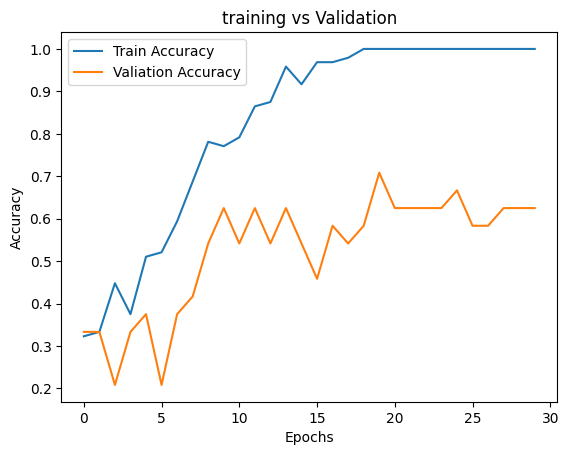

In [8]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Valiation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title("training vs Validation")

plt.legend()
plt.show()

## MINIST FASHION DATASET

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train.shape

(60000, 28, 28)

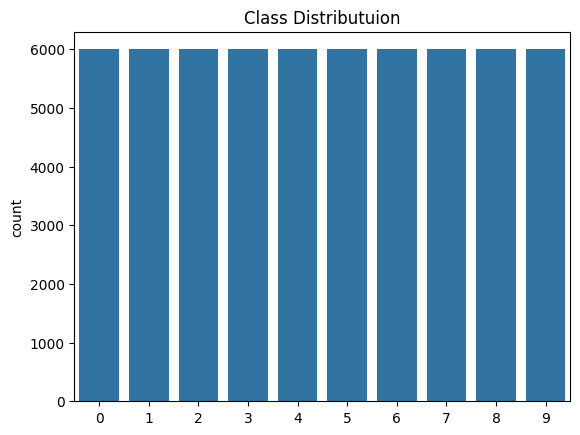

In [18]:
import seaborn as sns
sns.countplot(x=y_train)
plt.title("Class Distributuion")
plt.show()

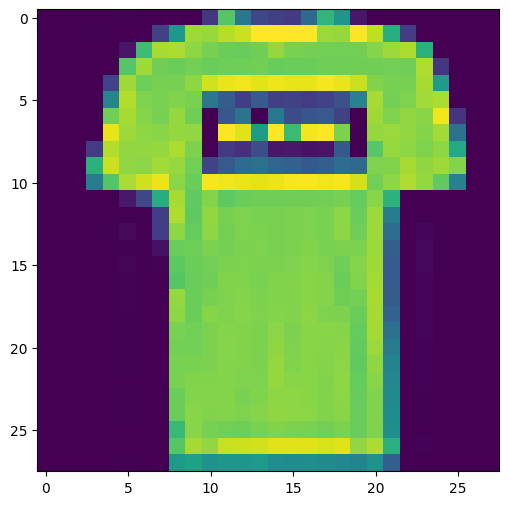

In [16]:
plt.figure(figsize=(6,6))
plt.imshow(x_train[1])
plt.show()

In [19]:
import tensorflow.keras.models as models
import tensorflow.keras.layers as layers

x_train, x_test = x_train/255, x_test/255

model = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

/home/tammy/Documents/collage_shit/lp5/.venv/lib64/python3.12/site-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1778167932.696416    6453 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778167932.696749   43334 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778167932.724483    6453 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the

In [23]:
history = model.fit(x_train, y_train, epochs=2, verbose=1)

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9513 - loss: 0.1307
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9549 - loss: 0.1207


In [ ]:
y_pred = model.predict(x_test)
y_pred = model.predict(x_test)
y_pred = y_pred.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1000
           1       0.99      0.97      0.98      1000
           2       0.83      0.90      0.86      1000
           3       0.91      0.92      0.91      1000
           4       0.83      0.90      0.86      1000
           5       0.97      0.98      0.98      1000
           6       0.80      0.71      0.75      1000
           7       0.97      0.94      0.96      1000
           8       0.97      0.98      0.98      1000
           9       0.95      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



[[818   4  32  28   5   1 107   0   5   0]
 [  3 974   1  15   2   0   4   0   1   0]
 [ 13   0 902   4  56   0  24   0   1   0]
 [ 11   4  14 915  31   0  18   0   7   0]
 [  0   0  55  16 901   1  26   0   1   0]
 [  0   0   0   0   0 984   0   6   0  10]
 [ 80   1  81  27  91   0 707   0  13   0]
 [  0   0   0   0   0  18   0 942   0  40]
 [  2   0   3   5   2   2   0   1 983   2]
 [  0   0   0   0   0   6   0  20   0 974]]


<Axes: >

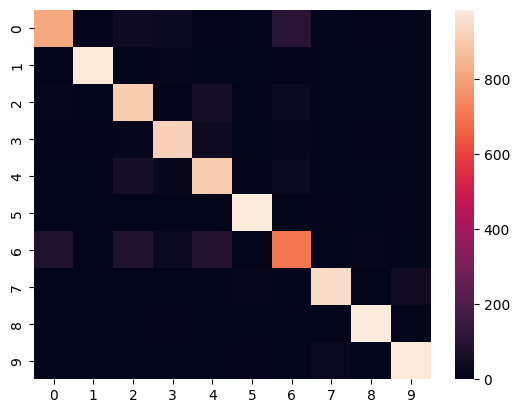

In [27]:
aaa = confusion_matrix(y_test, y_pred)
print(aaa)
sns.heatmap(aaa)